In [52]:
#%%script true
from google.colab import drive
drive.mount('/content/drive')

#%cd drive/MyDrive/Colab Notebooks/sentinel
#!pip install -e .
!pip install numpy pandas pyarrow scikit-learn matplotlib seaborn scipy -q

import sys
sys.path.insert(0, "/content/drive/MyDrive/Colab Notebooks/sentinel/src")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

from itertools import groupby
import statistics

import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns


In [54]:
TRAIN_PATH    = "/content/drive/MyDrive/Colab Notebooks/sentinel/data/raw/train.parquet"
TEST_PATH     = "/content/drive/MyDrive/Colab Notebooks/sentinel/data/raw/test.parquet"
TEST_NUM_ROWS = 521_280

In [55]:
pf = pq.ParquetFile(TRAIN_PATH)
columns = pf.schema.names
num_rows = pf.metadata.num_rows

print("columns: ", columns)
print("number of rows: ", num_rows)
print("measurements pro minute: ", num_rows / 14 / 365 / 24 / 60)

columns:  ['id', 'channel_1', 'channel_10', 'channel_11', 'channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_2', 'channel_20', 'channel_21', 'channel_22', 'channel_23', 'channel_24', 'channel_25', 'channel_26', 'channel_27', 'channel_28', 'channel_29', 'channel_3', 'channel_30', 'channel_31', 'channel_32', 'channel_33', 'channel_34', 'channel_35', 'channel_36', 'channel_37', 'channel_38', 'channel_39', 'channel_4', 'channel_40', 'channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46', 'channel_47', 'channel_48', 'channel_49', 'channel_5', 'channel_50', 'channel_51', 'channel_52', 'channel_53', 'channel_54', 'channel_55', 'channel_56', 'channel_57', 'channel_58', 'channel_59', 'channel_6', 'channel_60', 'channel_61', 'channel_62', 'channel_63', 'channel_64', 'channel_65', 'channel_66', 'channel_67', 'channel_68', 'channel_69', 'channel_7', 'channel_70', 'channel_71', 'channel_72', 'channel_7

In [56]:
anomaly = pq.read_table(TRAIN_PATH, columns=["is_anomaly"])
anomaly = anomaly.column("is_anomaly").to_pandas()

shortest anomaly:  1
median anomaly:  601.5
longest anomaly:  116061


(array([147.,  13.,  20.,   7.,   1.,   1.,   0.,   0.,   0.,   1.]),
 array([1.00000e+00, 1.16070e+04, 2.32130e+04, 3.48190e+04, 4.64250e+04,
        5.80310e+04, 6.96370e+04, 8.12430e+04, 9.28490e+04, 1.04455e+05,
        1.16061e+05]),
 <BarContainer object of 10 artists>)

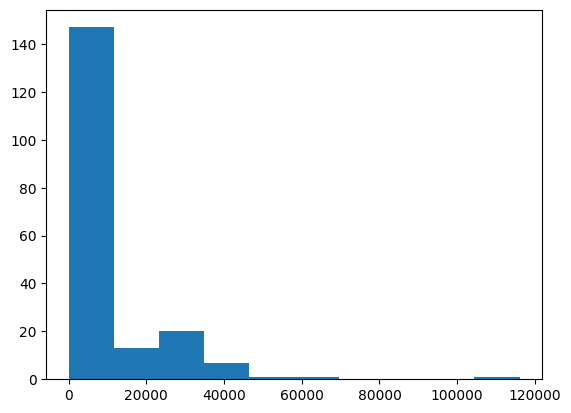

In [57]:
lengths = [len(list(g)) for k, g in groupby(anomaly) if k == 1]

print('shortest anomaly: ', min(lengths))
print('median anomaly: ', statistics.median(lengths))
print('longest anomaly: ', max(lengths))
plt.hist(lengths)

In [58]:
from sentinel.params import ANOMALY_COLOR, NOMINAL_COLOR
OVERVIEW_CHANNELS = ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']

In [59]:
def plot_with_anomaly(channels, start=0, end=num_rows, show_submission=False, aggregate=False):
    """Plot raw channel values with anomaly shading.

    aggregate=True  — sum all channels into a single subplot instead of one per channel.
    show_submission — append Kaggle test period highlighted in purple.
    """
    SAMPLE_FRAC = min(1.0, 280_000 / (end - start))
    SUB_COLOR   = '#7c3aed'

    # ── Training slice ────────────────────────────────────────────────────────
    meta = pq.read_table(TRAIN_PATH, columns=['id', 'is_anomaly']).to_pandas()
    meta = meta.sort_values('id').iloc[start:end]
    sample = meta.sample(frac=SAMPLE_FRAC, random_state=42).sort_values('id')
    idx_tr  = sample['id'].values
    anom_tr = sample['is_anomaly'].values

    data_tr = {'id': idx_tr, 'is_anomaly': anom_tr}
    for col in channels:
        df_col = pq.read_table(TRAIN_PATH, columns=['id', col]).to_pandas().set_index('id')
        data_tr[col] = df_col.reindex(idx_tr)[col].values
    df_train = pd.DataFrame(data_tr).set_index('id')

    # ── Submission slice (optional) ───────────────────────────────────────────
    df_test = None
    if show_submission:
        meta_test   = pq.read_table(TEST_PATH, columns=['id']).to_pandas().sort_values('id')
        sample_test = meta_test.sample(frac=min(1.0, 100_000 / TEST_NUM_ROWS),
                                        random_state=42).sort_values('id')
        idx_te = sample_test['id'].values
        data_te = {'id': idx_te}
        for col in channels:
            df_col = pq.read_table(TEST_PATH, columns=['id', col]).to_pandas().set_index('id')
            data_te[col] = df_col.reindex(idx_te)[col].values
        df_test = pd.DataFrame(data_te).set_index('id')

    # ── Aggregate: replace N channels with their sum ──────────────────────────
    if aggregate:
        lbl = 'sum(' + '+'.join(c.replace('channel_', 'ch') for c in channels) + ')'
        df_train[lbl] = df_train[channels].sum(axis=1)
        if df_test is not None:
            df_test[lbl] = df_test[channels].sum(axis=1)
        plot_channels = [lbl]
    else:
        plot_channels = channels

    # ── Plot ──────────────────────────────────────────────────────────────────
    n_ch = len(plot_channels)
    fig, axes = plt.subplots(n_ch, 1, figsize=(9, 2.5 * n_ch), sharex=True)
    if n_ch == 1:
        axes = [axes]

    # for ax, ch in zip(axes, plot_channels):
    #     if df_test is not None:
            #ax.axvspan(df_test.index.min(), df_test.index.max(),
            #           color=SUB_COLOR, alpha=0.08, linewidth=0)
            #ax.axvline(df_test.index.min(), color=SUB_COLOR, lw=0.9, ls='--', alpha=0.7)

        ax.plot(df_train.index, df_train[ch].values, lw=0.5, color=NOMINAL_COLOR, alpha=0.8)
        lo = np.nanpercentile(df_train[ch].values, 1)
        hi = np.nanpercentile(df_train[ch].values, 99)
        ax.set_ylim(lo - 0.2 * (hi - lo), hi + 0.2 * (hi - lo))

        in_anom = False; seg_start = None
        idx_arr = df_train.index.values; lab_arr = df_train['is_anomaly'].values
        for i in range(len(idx_arr)):
            if lab_arr[i] == 1 and not in_anom:
                seg_start = idx_arr[i]; in_anom = True
            elif lab_arr[i] == 0 and in_anom:
                ax.axvspan(seg_start, idx_arr[i], color=ANOMALY_COLOR, alpha=0.3, linewidth=0)
                in_anom = False
        if in_anom:
            ax.axvspan(seg_start, idx_arr[-1], color=ANOMALY_COLOR, alpha=0.3, linewidth=0)

        if df_test is not None:
            ax.plot(df_test.index, df_test[ch].values, lw=0.5, color=SUB_COLOR, alpha=0.7)

        ax.set_ylabel(ch, fontsize=8, rotation=0, labelpad=55, va='center')
        ax.tick_params(labelsize=7); ax.grid(alpha=0.4)

    patches = [mpatches.Patch(color=ANOMALY_COLOR, alpha=0.4, label='Anomaly')]
    if df_test is not None:
        patches.append(mpatches.Patch(color=SUB_COLOR, alpha=0.5, label='Submission (test)'))
    # axes[0].legend(handles=patches, fontsize=8, loc='upper right')
    axes[0].set_title(f'Channels  rows {start:,}–{end:,}' + (' + submission' if show_submission else ''),
                      fontsize=12, fontweight='bold')
    axes[-1].set_xlabel('Row index (time →)', fontsize=9)
    axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    fig.tight_layout(); plt.show()

In [60]:
def plot_envr(channels, start=0, end=num_rows,
              env_window=200, ma_window=5_000, show_submission=False, aggregate=False):
    """Plot envelope residual  envr = rolling_min(env_window) - centred_MA(ma_window).

    aggregate=True  — shows 2 subplots: envr(sum of channels) and sum(per-channel envr).
    show_submission — append Kaggle test period highlighted in purple.
    """
    PLOT_N      = 280_000
    PLOT_N_TEST = 100_000
    SUB_COLOR   = '#7c3aed'

    def _envr(series, env_w, ma_w):
        env = series.rolling(window=env_w, min_periods=1).min()
        #ma  = env.rolling(window=ma_w,     min_periods=1, center=True).mean()
        ma  = env.rolling(window=ma_w,     min_periods=1).mean()
        return (env - ma).values.astype(np.float32)

    # ── Training slice ────────────────────────────────────────────────────────
    meta = pq.read_table(TRAIN_PATH, columns=['id', 'is_anomaly']).to_pandas()
    meta = meta.sort_values('id').iloc[start:end]
    full_ids  = meta['id'].values
    anom_full = meta['is_anomaly'].values

    raw_tr   = {}
    envr_tr  = {}
    for col in channels:
        s = pq.read_table(TRAIN_PATH, columns=['id', col]).to_pandas().set_index('id').reindex(full_ids)[col]
        raw_tr[col]  = s.values.astype(np.float32)
        envr_tr[col] = _envr(s, env_window, ma_window)

    rng  = np.random.default_rng(42)
    sidx = np.sort(rng.choice(len(full_ids), size=min(len(full_ids), PLOT_N), replace=False))
    plot_ids  = full_ids[sidx]
    anom_plot = anom_full[sidx]

    # ── Submission slice (optional) ───────────────────────────────────────────
    sub_ids  = None
    raw_sub  = {}
    envr_sub = {}
    if show_submission:
        meta_test   = pq.read_table(TEST_PATH, columns=['id']).to_pandas().sort_values('id')
        full_ids_te = meta_test['id'].values
        sidx_te     = np.sort(rng.choice(len(full_ids_te),
                                          size=min(len(full_ids_te), PLOT_N_TEST), replace=False))
        sub_ids = full_ids_te[sidx_te]
        for col in channels:
            s = pq.read_table(TEST_PATH, columns=['id', col]).to_pandas().set_index('id').reindex(full_ids_te)[col]
            raw_sub[col]  = s.values.astype(np.float32)[sidx_te]
            envr_sub[col] = _envr(s, env_window, ma_window)[sidx_te]

    # ── Prepare plot series ───────────────────────────────────────────────────
    ch_lbl = '+'.join(c.replace('channel_', 'ch') for c in channels)
    if aggregate:
        sum_raw_tr = sum(raw_tr[c] for c in channels)
        plot_sigs_tr  = [_envr(pd.Series(sum_raw_tr), env_window, ma_window)[sidx],
                         sum(envr_tr[c][sidx] for c in channels)]
        plot_titles   = [f'envr( sum )   rolling_min({env_window})−MA({ma_window}) of [{ch_lbl}]',
                         f'sum( envr_i ) per-channel envr summed  [{ch_lbl}]']
        plot_ylabels  = ['envr(sum)', 'sum(envr_i)']
        if sub_ids is not None:
            sum_raw_sub = sum(raw_sub[c] for c in channels)
            plot_sigs_sub = [_envr(pd.Series(
                                 np.concatenate([sum_raw_tr, sum_raw_sub])
                             ), env_window, ma_window)[-len(sub_ids):],
                             sum(envr_sub[c] for c in channels)]
        else:
            plot_sigs_sub = [None, None]
    else:
        plot_sigs_tr  = [envr_tr[c][sidx] for c in channels]
        plot_titles   = channels
        plot_ylabels  = channels
        plot_sigs_sub = [envr_sub[c] if sub_ids is not None else None for c in channels]

    # ── Plot ──────────────────────────────────────────────────────────────────
    n_panels = len(plot_sigs_tr)
    fig, axes = plt.subplots(n_panels, 1, figsize=(9, 2.5 * n_panels), sharex=True)
    if n_panels == 1:
        axes = [axes]

    for ax, title, ylabel, sig_tr, sig_sub in zip(axes, plot_titles, plot_ylabels, plot_sigs_tr, plot_sigs_sub):
        if sub_ids is not None:
            ax.axvspan(sub_ids.min(), sub_ids.max(), color=SUB_COLOR, alpha=0.08, linewidth=0)
            ax.axvline(sub_ids.min(), color=SUB_COLOR, lw=0.9, ls='--', alpha=0.7)

        ax.plot(plot_ids, sig_tr, lw=0.5, color=NOMINAL_COLOR, alpha=0.8)
        ax.axhline(0, color='grey', lw=0.6, ls=':', alpha=0.6)
        ax.axhline(0.02, lw=0.6, ls='--', alpha=0.6)
        ax.axhline(-0.02, lw=0.6, ls='--', alpha=0.6)
        ax.set_ylim(-0.04, 0.04)

        in_anom = False; seg_start = None
        # for i in range(len(plot_ids)):
        #     if anom_plot[i] == 1 and not in_anom:
        #         seg_start = plot_ids[i]; in_anom = True
        #     elif anom_plot[i] == 0 and in_anom:
        #         ax.axvspan(seg_start, plot_ids[i], color=ANOMALY_COLOR, alpha=0.3, linewidth=0)
        #         in_anom = False
        # if in_anom:
        #     ax.axvspan(seg_start, plot_ids[-1], color=ANOMALY_COLOR, alpha=0.3, linewidth=0)

        if sig_sub is not None:
            ax.plot(sub_ids, sig_sub, lw=0.5, color=SUB_COLOR, alpha=0.7)

        ax.set_ylabel(ylabel, fontsize=8, rotation=0, labelpad=55, va='center')
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7); ax.grid(alpha=0.4)

    patches = [mpatches.Patch(color=ANOMALY_COLOR, alpha=0.4, label='Anomaly')]
    if sub_ids is not None:
        patches.append(mpatches.Patch(color=SUB_COLOR, alpha=0.5, label='Submission'))
    # axes[0].legend(handles=patches, fontsize=8, loc='upper right')
    axes[-1].set_xlabel('Row index (time →)', fontsize=9)
    axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    fig.tight_layout(); plt.show()

## Envelope residual (envr) — env channels + submission

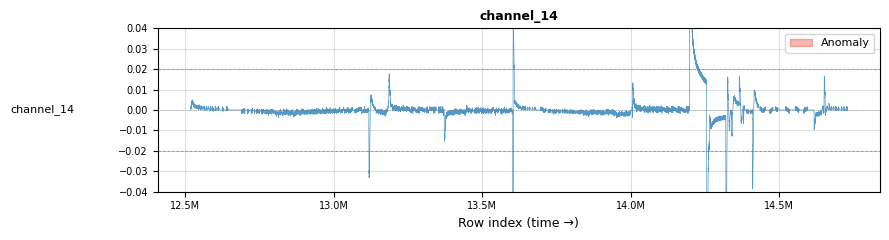

In [61]:
ENV_CHANNELS = ['channel_14']

# full training range + submission
plot_envr(ENV_CHANNELS, start=int(0.85*num_rows), show_submission=False)

['channel_14']


KeyError: 'channel_46'

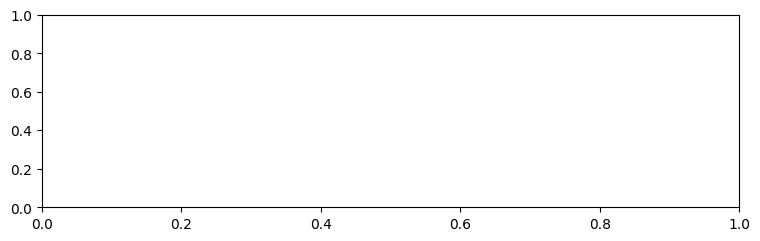

In [64]:
# raw signal for the same channels (for comparison)
#plot_with_anomaly(ENV_CHANNELS, start=int(0.7*num_rows), show_submission=True)
print(ENV_CHANNELS)
plot_with_anomaly(ENV_CHANNELS, start=int(0.85*num_rows), show_submission=False)

In [ ]:
PLOT_CHANNELS = ['channel_14', 'channel_21', 'channel_29', 'channel_39']
# PLOT_CHANNELS = ['channel_14', 'channel_21', 'channel_23', 'channel_29', 'channel_31', 'channel_39']
# PLOT_CHANNELS = ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']

plot_with_anomaly(PLOT_CHANNELS, start=int(0.0*num_rows), end=int(0.1*num_rows), show_submission=False, aggregate=True)
plot_envr(PLOT_CHANNELS, start=int(0.0*num_rows), end=int(0.1*num_rows), show_submission=False, aggregate=True)

In [ ]:
PLOT_CHANNELS = ['channel_14', 'channel_21', 'channel_29', 'channel_39']
# PLOT_CHANNELS = ['channel_14', 'channel_21', 'channel_23', 'channel_29', 'channel_31', 'channel_39']
# PLOT_CHANNELS = ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']

plot_with_anomaly(PLOT_CHANNELS, start=int(0.99*num_rows), show_submission=True, aggregate=True)
plot_envr(PLOT_CHANNELS, start=int(0.99*num_rows), show_submission=True, aggregate=True)

In [ ]:
# 1. sample indices
SAMPLE_N = 100_000

meta = pq.read_table(TRAIN_PATH, columns=["id", "is_anomaly"]).to_pandas()
sample_meta = meta.sample(n=SAMPLE_N, random_state=42)

idx_sample = sample_meta["id"].values
anom_sample = sample_meta["is_anomaly"].values

# split masks once to avoid recomputation
nom_mask = anom_sample == 0
anom_mask = anom_sample == 1

# 2. plotting layout
DIST_CHANNELS = OVERVIEW_CHANNELS

ncols = 2
nrows = int(np.ceil(len(DIST_CHANNELS) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

# 3. load each column separately
for i, ch in enumerate(DIST_CHANNELS):
    ax = axes[i]

    # load only index + current channel
    df = pq.read_table(TRAIN_PATH, columns=["id", ch]).to_pandas().set_index("id")

    # align to sampled indices
    values = df.loc[idx_sample, ch].values

    nom_values = values[nom_mask]
    anom_values = values[anom_mask]

    # plot distributions
    sns.histplot(nom_values, ax=ax, color=NOMINAL_COLOR, alpha=0.5, stat="density", bins=50, kde=True, label="Nominal")
    sns.histplot(anom_values, ax=ax, color=ANOMALY_COLOR, alpha=0.5, stat="density", bins=50, kde=True, label="Anomaly")

    ax.set_title(ch, fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(labelsize=7)
    ax.set_xlim(0.7, 0.87)

    if i == 0:
        ax.legend(fontsize=7)

# hide unused subplots
for j in range(len(DIST_CHANNELS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Channel Value Distributions: Nominal vs Anomaly (column-wise load)", fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

In [ ]:
names = ['channel_' + str(n) for n in [14, 26, 41, 57]]
names

In [ ]:
plot_with_anomaly(names, end=12_000_000)